# Notebook 03 — Collateral Management & MPOR Sensitivity

This notebook provides a comprehensive analysis of collateral dynamics under a CSA (Credit Support Annex),
focusing on:

1. **Variation Margin (VM)** — daily MtM exchange, threshold, MTA effects
2. **Initial Margin (IM)** — VaR-based IM reducing exposure during MPOR
3. **MPOR Sensitivity** — 5 / 10 / 15 / 20-day MPOR impact on EE and EEPE
4. **Clearing vs Bilateral** — CCP (5d MPOR) vs OTC bilateral (10d MPOR)
5. **Dispute Scenario** — doubled MPOR under CRR3 Art. 285(4)
6. **CollateralManager Full Report** — gross / VM-only / VM+IM comparison

---
**Key regulatory references:**
- BCBS (2014) SA-CCR — MPOR calibration table
- CRR3 Article 285(4) — disputed margin calls → 2× MPOR
- Gregory (2015) *The xVA Challenge* — Ch. 7: Collateral
- ISDA SIMM Methodology v2.5

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from ccr.simulation import HullWhite1F
from ccr.exposure import ExposureProfile, NettingSet
from ccr.collateral import (
    CSAParameters, VMEngine, IMEngine, MPORAnalyser, CollateralManager
)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
RNG_SEED = 42

## 1. Portfolio Setup — IRS under Hull-White 1F

We simulate a 5-year payer IRS (receive fixed at 3%, pay floating) under the Hull-White 1F model.
The MtM of a payer IRS is approximately:

$$V(t) \approx N \cdot (r_{market}(t) - r_{fixed}) \cdot \text{Annuity}(t)$$

Rising rates → positive MtM (payer benefits).

In [2]:
# ─── Simulation parameters ────────────────────────────────────────────────────
N_PATHS   = 2_000
N_STEPS   = 520
HORIZON   = 5.0        # years
NOTIONAL  = 10_000_000 # EUR 10M
FIXED_RATE = 0.03

hw = HullWhite1F(r0=0.03, a=0.05, sigma=0.010)
sim = hw.simulate(n_paths=N_PATHS, n_steps=N_STEPS, horizon=HORIZON, seed=RNG_SEED)

time_grid = sim.time_grid[1:]  # exclude t=0 (annuity not defined at expiry)
rate_paths = sim.paths[:, 1:]  # (N_PATHS, N_STEPS)

# Payer IRS MtM: N * (r_mkt - r_fixed) * Annuity
# Annuity(t) ≈ (1 - exp(-r*T_rem)) / r  with T_rem = HORIZON - t
T_rem = HORIZON - time_grid  # remaining maturity at each node
# Broadcast: rate_paths (N_PATHS, N_STEPS), T_rem (N_STEPS,)
annuity = np.where(np.abs(rate_paths) < 1e-6, T_rem, (1 - np.exp(-rate_paths*T_rem)) / rate_paths)

mtm_matrix = NOTIONAL * (rate_paths - FIXED_RATE) * annuity  # payer

print(f'MtM matrix shape : {mtm_matrix.shape}')
print(f'Time grid        : 0.08y → {time_grid[-1]:.1f}y  ({len(time_grid)} steps)')
print(f'MtM range        : [{mtm_matrix.min():,.0f}, {mtm_matrix.max():,.0f}] EUR')
print(f'Mean MtM at t=1y : {mtm_matrix[:, int(N_STEPS/5)].mean():,.0f} EUR')

MtM matrix shape : (2000, 520)
Time grid        : 0.08y → 5.0y  (520 steps)
MtM range        : [-1,646,922, 1,406,117] EUR
Mean MtM at t=1y : -6,976 EUR


## 2. Gross Exposure Profile (no collateral)

Without any collateral, the counterparty credit exposure equals:
$$\text{EE}(t) = \mathbb{E}[\max(V(t), 0)]$$

For a payer IRS, this produces the characteristic **exposure hump** — exposure peaks
around mid-life and declines as the swap approaches maturity.

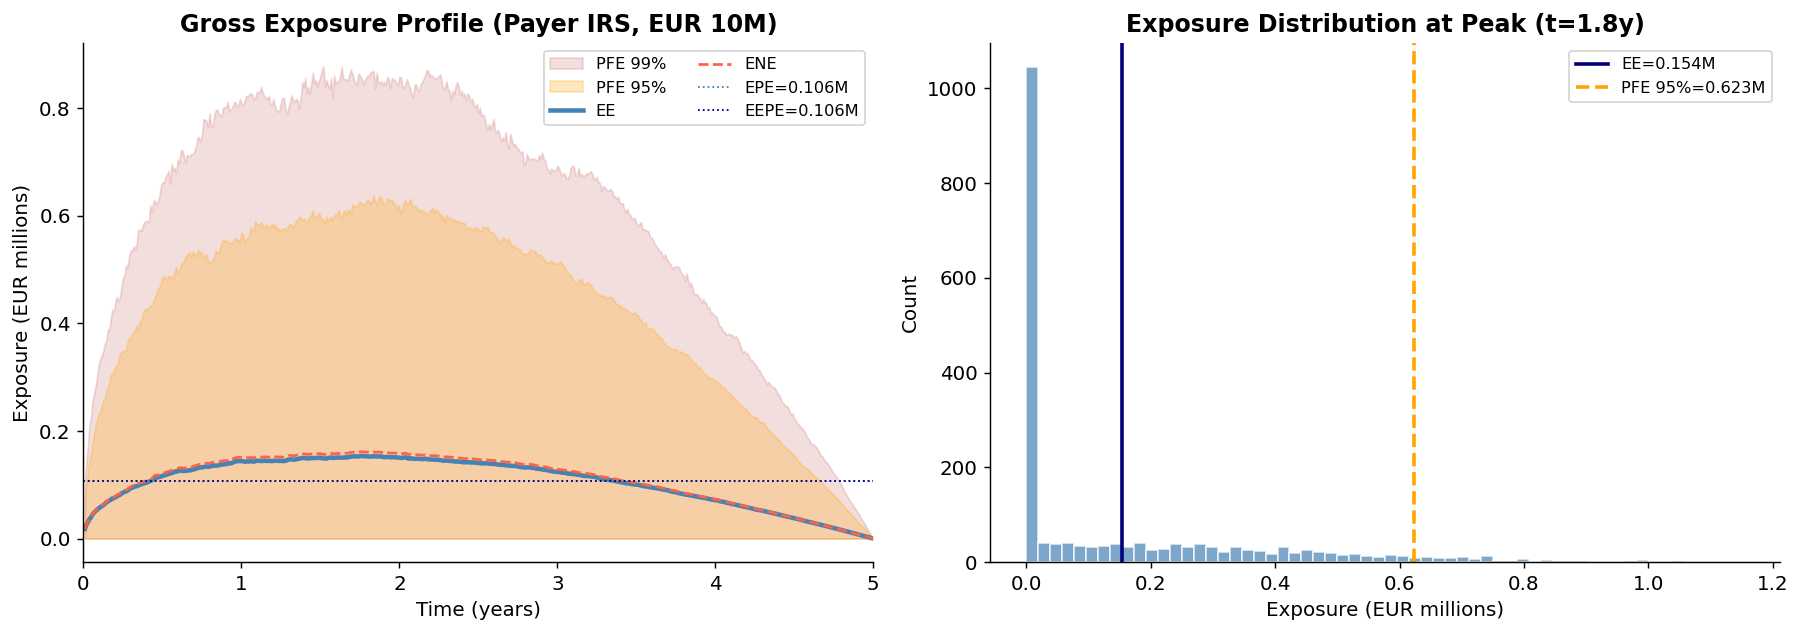


── Gross Scalar Metrics ─────────────────────────────────────
  EPE         : EUR 0.1068M
  EEPE        : EUR 0.1064M
  EAD_IMM     : EUR 0.1490M
  MaxPFE      : EUR 0.6376M
  MaxEE       : EUR 0.1536M
  n_paths     : EUR 0.0020M


In [3]:
gross_profile = ExposureProfile(mtm_matrix, time_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: EE, ENE, PFE 95% ───────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(time_grid, gross_profile.pfe(0.99)/1e6, alpha=0.15, color='firebrick', label='PFE 99%')
ax.fill_between(time_grid, gross_profile.pfe(0.95)/1e6, alpha=0.25, color='orange', label='PFE 95%')
ax.plot(time_grid, gross_profile.ee()/1e6,  color='steelblue',  lw=2.5, label='EE')
ax.plot(time_grid, gross_profile.ene()/1e6, color='tomato',     lw=1.5, ls='--', label='ENE')
ax.axhline(gross_profile.epe()/1e6,  color='steelblue',  lw=1, ls=':', label=f'EPE={gross_profile.epe()/1e6:.3f}M')
ax.axhline(gross_profile.eepe()/1e6, color='navy',        lw=1, ls=':', label=f'EEPE={gross_profile.eepe()/1e6:.3f}M')
ax.set_title('Gross Exposure Profile (Payer IRS, EUR 10M)', fontweight='bold')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Exposure (EUR millions)')
ax.legend(fontsize=9, ncol=2)
ax.set_xlim(0, HORIZON)

# ── Right: EE histogram at peak exposure ─────────────────────────────────────
ax2 = axes[1]
peak_idx = np.argmax(gross_profile.ee())
exposure_at_peak = np.maximum(mtm_matrix[:, peak_idx], 0.0) / 1e6
ax2.hist(exposure_at_peak, bins=60, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(gross_profile.ee()[peak_idx]/1e6, color='navy', lw=2, label=f'EE={gross_profile.ee()[peak_idx]/1e6:.3f}M')
ax2.axvline(gross_profile.pfe(0.95)[peak_idx]/1e6, color='orange', lw=2, ls='--', label=f'PFE 95%={gross_profile.pfe(0.95)[peak_idx]/1e6:.3f}M')
ax2.set_title(f'Exposure Distribution at Peak (t={time_grid[peak_idx]:.1f}y)', fontweight='bold')
ax2.set_xlabel('Exposure (EUR millions)')
ax2.set_ylabel('Count')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

m = gross_profile.scalar_metrics()
print('\n── Gross Scalar Metrics ─────────────────────────────────────')
for k, v in m.items():
    print(f'  {k:<12}: EUR {v/1e6:.4f}M')

## 3. Variation Margin (VM) Dynamics

Under a **zero-threshold CSA**, the counterparty posts VM daily to cover the current MtM:

$$C_{VM}(t) = \max(V(t - \delta_{MPOR}) - TH, 0) - IA$$

The residual exposure after VM is approximately the **MtM change over the MPOR**:

$$E_{VM}(t) \approx \max(V(t) - V(t - \delta_{MPOR}),\; 0)$$

This is the key insight: **collateral eliminates the level exposure, leaving only the gap risk
over the MPOR window**.

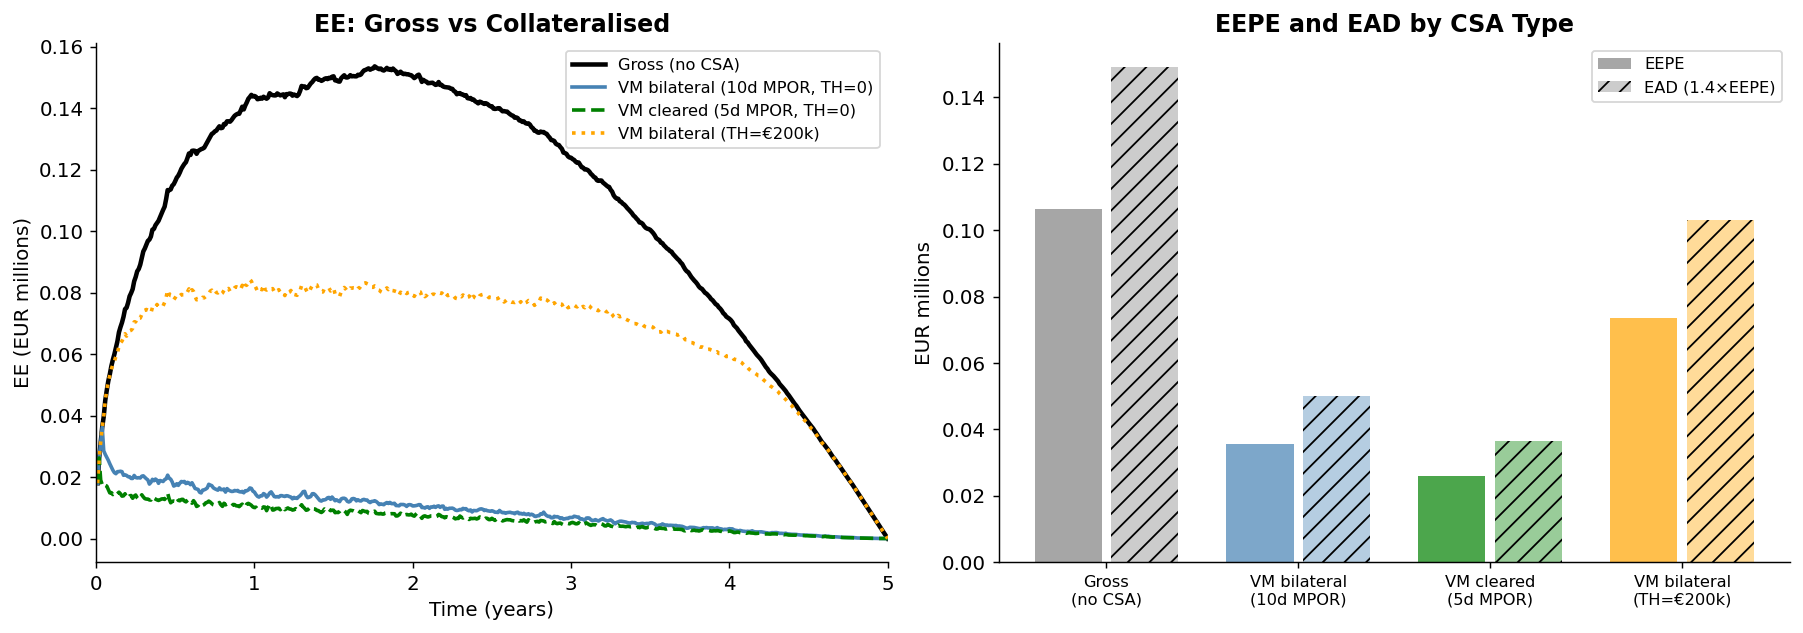


── VM Effectiveness ──────────────────────────────────────────
  Gross EEPE          : EUR 0.1064M
  VM bilateral (10d)  : EUR 0.0357M  (-66.4%)
  VM cleared (5d)     : EUR 0.0260M  (-75.6%)
  VM bilateral (TH=200k): EUR 0.0735M  (-30.9%)


In [4]:
# ─── Three CSA configurations ─────────────────────────────────────────────────
csa_bilateral  = CSAParameters.zero_threshold_bilateral(mpor_days=10)  # standard OTC
csa_cleared    = CSAParameters.cleared_ccp()                            # CCP: 5d MPOR
csa_high_th    = CSAParameters(threshold_we=200_000, mta_we=50_000,    # €200k threshold
                               mpor_days=10)

vm_bilateral = VMEngine(csa_bilateral)
vm_cleared   = VMEngine(csa_cleared)
vm_high_th   = VMEngine(csa_high_th)

exp_bilateral = vm_bilateral.collateral_adjusted_exposure(mtm_matrix, time_grid)
exp_cleared   = vm_cleared.collateral_adjusted_exposure(mtm_matrix, time_grid)
exp_high_th   = vm_high_th.collateral_adjusted_exposure(mtm_matrix, time_grid)

p_bilateral = ExposureProfile(exp_bilateral, time_grid)
p_cleared   = ExposureProfile(exp_cleared,   time_grid)
p_high_th   = ExposureProfile(exp_high_th,   time_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: EE comparison ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(time_grid, gross_profile.ee()/1e6, color='black',     lw=2.5, ls='-',  label='Gross (no CSA)')
ax.plot(time_grid, p_bilateral.ee()/1e6,   color='steelblue', lw=2.0, ls='-',  label='VM bilateral (10d MPOR, TH=0)')
ax.plot(time_grid, p_cleared.ee()/1e6,     color='green',     lw=2.0, ls='--', label='VM cleared (5d MPOR, TH=0)')
ax.plot(time_grid, p_high_th.ee()/1e6,     color='orange',    lw=2.0, ls=':',  label='VM bilateral (TH=€200k)')
ax.set_title('EE: Gross vs Collateralised', fontweight='bold')
ax.set_xlabel('Time (years)')
ax.set_ylabel('EE (EUR millions)')
ax.legend(fontsize=9)
ax.set_xlim(0, HORIZON)

# ── Right: EEPE bar chart ─────────────────────────────────────────────────────
ax2 = axes[1]
labels = ['Gross\n(no CSA)', 'VM bilateral\n(10d MPOR)', 'VM cleared\n(5d MPOR)', 'VM bilateral\n(TH=€200k)']
eepes  = [gross_profile.eepe(), p_bilateral.eepe(), p_cleared.eepe(), p_high_th.eepe()]
eads   = [gross_profile.ead_imm(), p_bilateral.ead_imm(), p_cleared.ead_imm(), p_high_th.ead_imm()]
colors = ['grey', 'steelblue', 'green', 'orange']
x = np.arange(len(labels))
bars = ax2.bar(x - 0.2, [v/1e6 for v in eepes], 0.35, label='EEPE', color=colors, alpha=0.7)
bars2 = ax2.bar(x + 0.2, [v/1e6 for v in eads],  0.35, label='EAD (1.4×EEPE)', color=colors, alpha=0.4, hatch='//')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('EUR millions')
ax2.set_title('EEPE and EAD by CSA Type', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\n── VM Effectiveness ──────────────────────────────────────────')
print(f'  Gross EEPE          : EUR {gross_profile.eepe()/1e6:.4f}M')
print(f'  VM bilateral (10d)  : EUR {p_bilateral.eepe()/1e6:.4f}M  '
      f'(-{100*(1-p_bilateral.eepe()/gross_profile.eepe()):.1f}%)')
print(f'  VM cleared (5d)     : EUR {p_cleared.eepe()/1e6:.4f}M  '
      f'(-{100*(1-p_cleared.eepe()/gross_profile.eepe()):.1f}%)')
print(f'  VM bilateral (TH=200k): EUR {p_high_th.eepe()/1e6:.4f}M  '
      f'(-{100*(1-p_high_th.eepe()/gross_profile.eepe()):.1f}%)')

## 4. MPOR Sensitivity Analysis

The **Margin Period of Risk (MPOR)** is the time window between the last successful margin
call and the final close-out of the portfolio after a counterparty default.

Regulatory minimums (BCBS/CRR3):
| Agreement type | Min MPOR |
|---|---|
| OTC bilateral (liquid) | **10 days** |
| OTC bilateral (illiquid, >5000 trades) | **20 days** |
| Cleared (CCP) | **5 days** |
| Disputed (≥20d delays in past 2Q) | **2× normal** |

The exposure scales roughly as $\sqrt{\delta_{MPOR}}$ — doubling MPOR raises exposure by ~41%.

── MPOR Sensitivity Table ────────────────────────────────────────────────
              EE_mean      EE_max        EEPE     EAD_IMM  MaxPFE_95%
MPOR_days                                                            
0             0.0093M     0.0184M     0.0182M     0.0255M     0.0751M
5             0.0132M     0.0261M     0.0255M     0.0357M     0.1055M
10            0.0187M     0.0361M     0.0347M     0.0486M     0.1487M
15            0.0229M     0.0446M     0.0420M     0.0588M     0.1825M
20            0.0264M     0.0515M     0.0475M     0.0665M     0.2133M


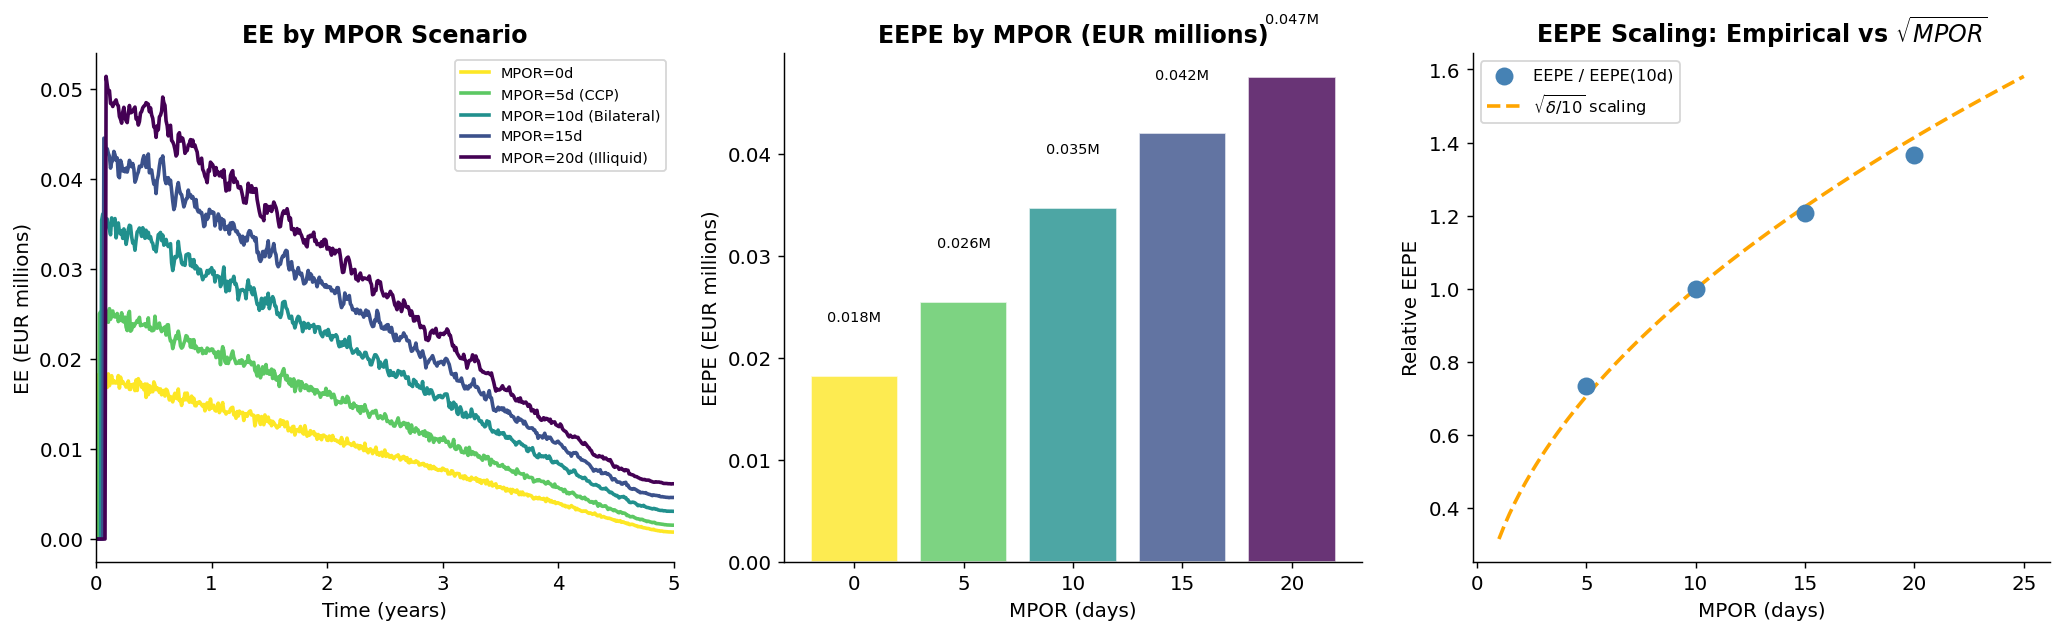


  EEPE(5d) / EEPE(10d) = 0.735  (sqrt scaling: 0.707)
  EEPE(20d)/ EEPE(10d) = 1.367  (sqrt scaling: 1.414)


In [5]:
mpor_scenarios = [0, 5, 10, 15, 20]
df_mpor = MPORAnalyser.compare_mpor_scenarios(mtm_matrix, time_grid, mpor_scenarios)

print('── MPOR Sensitivity Table ────────────────────────────────────────────────')
print(df_mpor.to_string(
    float_format=lambda x: f'{x/1e6:>10.4f}M' if abs(x) > 1000 else f'{x:>10.2f}'
))

# Compute EEPE relative to 10-day baseline
eepe_10 = df_mpor.loc[10, 'EEPE']
df_mpor['EEPE_ratio'] = df_mpor['EEPE'] / eepe_10
df_mpor['sqrt_ratio'] = np.sqrt(np.array(mpor_scenarios) / 10.0).clip(1e-4)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: EE profiles for each MPOR ──────────────────────────────────────────
ax = axes[0]
cmap = plt.cm.viridis_r
colors_mpor = [cmap(i / (len(mpor_scenarios) - 1)) for i in range(len(mpor_scenarios))]
for mpor, col in zip(mpor_scenarios, colors_mpor):
    exp_m = MPORAnalyser.mpor_exposure_profile(mtm_matrix, time_grid, mpor)
    p_m   = ExposureProfile(exp_m, time_grid)
    lbl   = f'MPOR={mpor}d' + (' (CCP)' if mpor==5 else ' (Bilateral)' if mpor==10 else
                                ' (Illiquid)' if mpor==20 else '')
    ax.plot(time_grid, p_m.ee()/1e6, color=col, lw=2.0, label=lbl)
ax.set_title('EE by MPOR Scenario', fontweight='bold')
ax.set_xlabel('Time (years)')
ax.set_ylabel('EE (EUR millions)')
ax.legend(fontsize=8)
ax.set_xlim(0, HORIZON)

# ── Middle: EEPE bar chart ────────────────────────────────────────────────────
ax2 = axes[1]
bar_colors = [colors_mpor[i] for i in range(len(mpor_scenarios))]
ax2.bar([str(m) for m in mpor_scenarios],
        df_mpor['EEPE'].values / 1e6,
        color=bar_colors, alpha=0.8, edgecolor='white')
ax2.set_title('EEPE by MPOR (EUR millions)', fontweight='bold')
ax2.set_xlabel('MPOR (days)')
ax2.set_ylabel('EEPE (EUR millions)')
# Annotate values
for i, (mpor, row) in enumerate(df_mpor.iterrows()):
    ax2.text(i, row['EEPE']/1e6 + 0.005, f"{row['EEPE']/1e6:.3f}M",
             ha='center', va='bottom', fontsize=8)

# ── Right: EEPE ratio vs sqrt(MPOR/10) ───────────────────────────────────────
ax3 = axes[2]
mpor_arr = np.array(mpor_scenarios)
valid = mpor_arr > 0
ax3.scatter(mpor_arr[valid], df_mpor['EEPE_ratio'].values[valid],
            color='steelblue', s=80, zorder=5, label='EEPE / EEPE(10d)')
# Theoretical sqrt scaling
mpor_cont = np.linspace(1, 25, 100)
ax3.plot(mpor_cont, np.sqrt(mpor_cont / 10.0), color='orange', ls='--', lw=2,
         label=r'$\sqrt{\delta / 10}$ scaling')
ax3.set_title(r'EEPE Scaling: Empirical vs $\sqrt{MPOR}$', fontweight='bold')
ax3.set_xlabel('MPOR (days)')
ax3.set_ylabel('Relative EEPE')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'\n  EEPE(5d) / EEPE(10d) = {df_mpor.loc[5,"EEPE"]/eepe_10:.3f}  (sqrt scaling: {np.sqrt(0.5):.3f})')
print(f'  EEPE(20d)/ EEPE(10d) = {df_mpor.loc[20,"EEPE"]/eepe_10:.3f}  (sqrt scaling: {np.sqrt(2.0):.3f})')

## 5. Clearing vs Bilateral — Capital Impact

Central clearing reduces MPOR from 10d (bilateral) to 5d (CCP), which in turn reduces
EEPE and IMM capital charge. However, CCPs require posting IM upfront.

The regulatory capital benefit of clearing (per Basel BCBS SA-CCR/IMM) is driven by:
- Lower MPOR → lower gap risk
- Risk-weighted assets (RWA) = EAD × Risk Weight
- For CCPs, the risk weight on the trade exposure is 2% (vs. 20-100% for bilateral)

── Capital Requirement: Clearing vs Bilateral ────────────────────────────
                   Agreement EEPE (EUR) EAD = 1.4×EEPE (EUR) Risk Weight RWA (EUR) Capital (8% of RWA)
Bilateral (10d MPOR, RW 20%)     35,711               49,995         20%     9,999                 800
Cleared CCP (5d MPOR, RW 2%)     25,965               36,351          2%       727                  58
High Threshold (10d, RW 20%)     73,507              102,909         20%    20,582               1,647


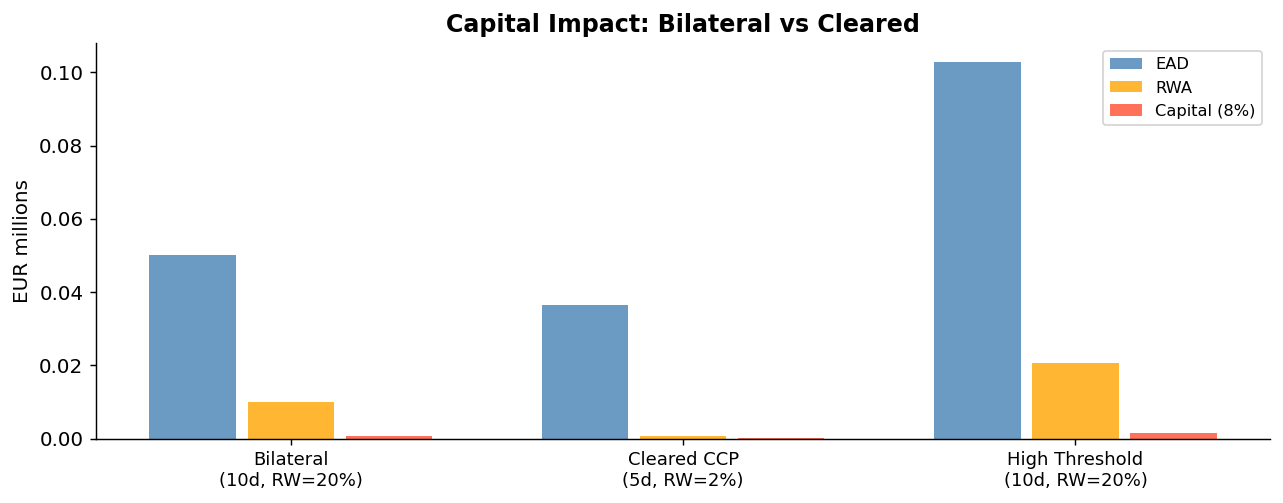

In [6]:
# IMM capital: K = EAD × RW × 8%
RW_BILATERAL = 0.20  # 20% risk weight for typical BBB counterparty
RW_CCP       = 0.02  # 2% risk weight for qualified CCP
CAPITAL_RATIO = 0.08  # Basel III minimum Tier 1 + Tier 2

# Build comparison DataFrame
rows = []
for label, profile, rw in [
    ('Bilateral (10d MPOR, RW 20%)',  p_bilateral, RW_BILATERAL),
    ('Cleared CCP (5d MPOR, RW 2%)',  p_cleared,   RW_CCP),
    ('High Threshold (10d, RW 20%)', p_high_th,   RW_BILATERAL),
]:
    eepe = profile.eepe()
    ead  = profile.ead_imm()
    rwa  = ead * rw
    rows.append({
        'Agreement':         label,
        'EEPE (EUR)':        f'{eepe:,.0f}',
        'EAD = 1.4×EEPE (EUR)': f'{ead:,.0f}',
        'Risk Weight':       f'{rw*100:.0f}%',
        'RWA (EUR)':         f'{rwa:,.0f}',
        'Capital (8% of RWA)': f'{rwa * CAPITAL_RATIO:,.0f}',
    })

df_capital = pd.DataFrame(rows)
print('── Capital Requirement: Clearing vs Bilateral ────────────────────────────')
print(df_capital.to_string(index=False))

# Visualise capital requirements
fig, ax = plt.subplots(figsize=(10, 4))
labels_cap = ['Bilateral\n(10d, RW=20%)', 'Cleared CCP\n(5d, RW=2%)', 'High Threshold\n(10d, RW=20%)']
ead_vals  = [p_bilateral.ead_imm(), p_cleared.ead_imm(), p_high_th.ead_imm()]
rwa_vals  = [p_bilateral.ead_imm() * RW_BILATERAL, p_cleared.ead_imm() * RW_CCP,
             p_high_th.ead_imm() * RW_BILATERAL]
cap_vals  = [r * CAPITAL_RATIO for r in rwa_vals]

x = np.arange(len(labels_cap))
ax.bar(x - 0.25, [v/1e6 for v in ead_vals],  0.22, label='EAD',     color='steelblue', alpha=0.8)
ax.bar(x,        [v/1e6 for v in rwa_vals],   0.22, label='RWA',     color='orange',    alpha=0.8)
ax.bar(x + 0.25, [v/1e6 for v in cap_vals],   0.22, label='Capital (8%)', color='tomato', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels_cap, fontsize=10)
ax.set_ylabel('EUR millions')
ax.set_title('Capital Impact: Bilateral vs Cleared', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Dispute Scenario — CRR3 Article 285(4)

Under CRR3 Article 285(4), if a bank has experienced **more than 20 disputed margin calls
lasting more than 2 days in any two consecutive quarters**, the regulatory MPOR must be
**doubled** for that counterparty.

This represents a severe operational risk: operational difficulties in margin call resolution
translate directly into higher capital requirements.

── CRR3 Art. 285(4) Dispute Scenario ────────────────────────────────────
Metric                Normal (10d)      Dispute (20d)    Ratio
--------------------------------------------------------------
EPE                      0.0316M           0.0424M   1.344×
EEPE                     0.0347M           0.0475M   1.367×
EAD_IMM                  0.0486M           0.0665M   1.367×
MaxPFE                   0.1487M           0.2133M   1.434×
MaxEE                    0.0361M           0.0515M   1.423×

Theoretical √(20/10) scaling: 1.414×


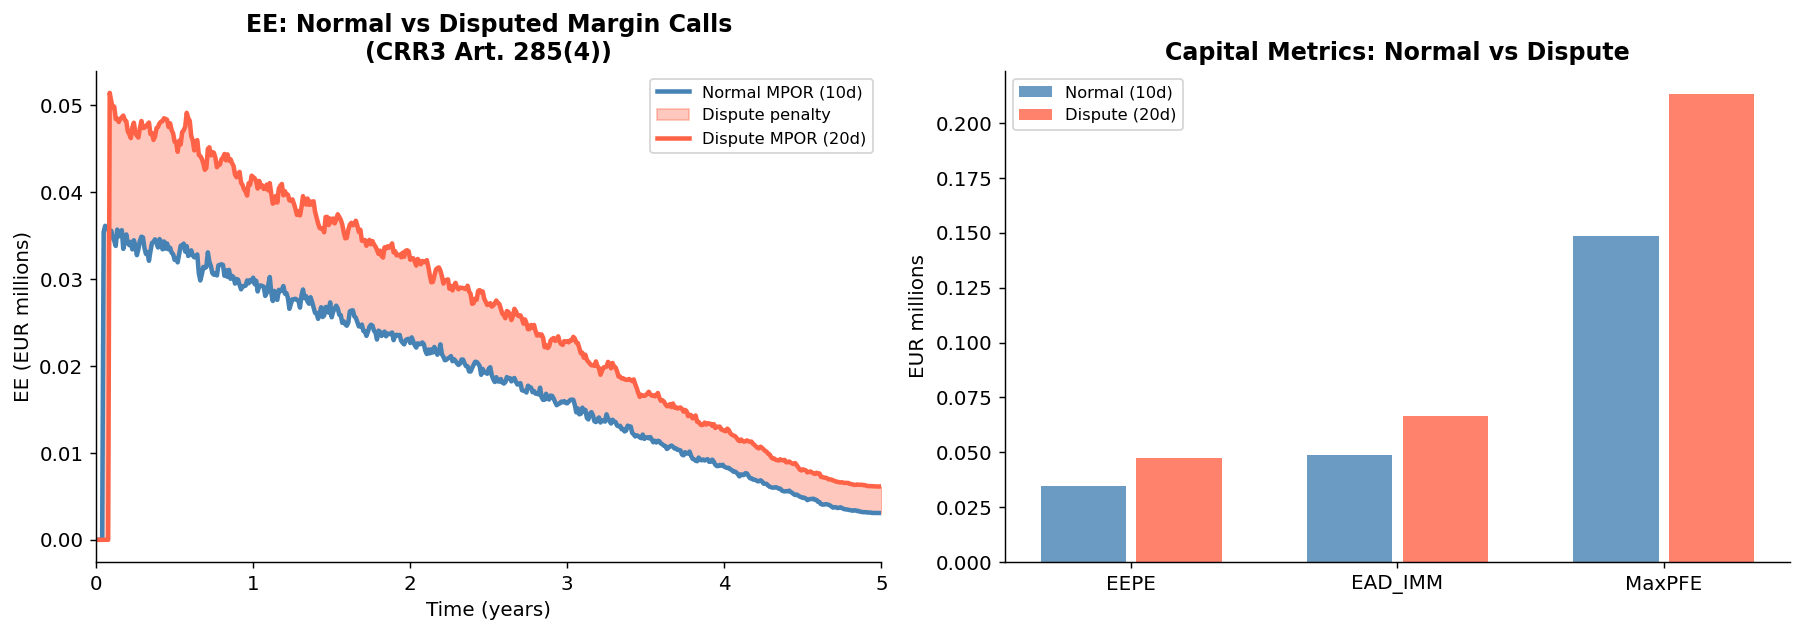

In [7]:
dispute = MPORAnalyser.dispute_scenario(mtm_matrix, time_grid, base_mpor=10)

print('── CRR3 Art. 285(4) Dispute Scenario ────────────────────────────────────')
print(f'{"Metric":<15} {"Normal (10d)":>18} {"Dispute (20d)":>18} {"Ratio":>8}')
print('-' * 62)
for key in ['EPE', 'EEPE', 'EAD_IMM', 'MaxPFE', 'MaxEE']:
    normal  = dispute['Normal'][key]
    disp    = dispute['Dispute (2×MPOR)'][key]
    ratio   = disp / normal if normal > 0 else float('nan')
    print(f'{key:<15} {normal/1e6:>15.4f}M  {disp/1e6:>15.4f}M  {ratio:>6.3f}×')

print(f'\nTheoretical √(20/10) scaling: {np.sqrt(2):.3f}×')

# Visualise EE profiles: normal vs dispute
exp_normal  = MPORAnalyser.mpor_exposure_profile(mtm_matrix, time_grid, 10)
exp_dispute = MPORAnalyser.mpor_exposure_profile(mtm_matrix, time_grid, 20)
p_normal  = ExposureProfile(exp_normal,  time_grid)
p_dispute = ExposureProfile(exp_dispute, time_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(time_grid, p_normal.ee()/1e6,  color='steelblue', lw=2.5, label='Normal MPOR (10d)')
ax.fill_between(time_grid, p_normal.ee()/1e6, p_dispute.ee()/1e6,
                color='tomato', alpha=0.35, label='Dispute penalty')
ax.plot(time_grid, p_dispute.ee()/1e6, color='tomato',    lw=2.5, label='Dispute MPOR (20d)')
ax.set_title('EE: Normal vs Disputed Margin Calls\n(CRR3 Art. 285(4))', fontweight='bold')
ax.set_xlabel('Time (years)')
ax.set_ylabel('EE (EUR millions)')
ax.legend(fontsize=9)
ax.set_xlim(0, HORIZON)

ax2 = axes[1]
metrics_norm = ['EEPE', 'EAD_IMM', 'MaxPFE']
vals_normal  = [dispute['Normal'][k]/1e6 for k in metrics_norm]
vals_dispute = [dispute['Dispute (2×MPOR)'][k]/1e6 for k in metrics_norm]
x = np.arange(len(metrics_norm))
ax2.bar(x - 0.18, vals_normal,  0.32, color='steelblue', alpha=0.8, label='Normal (10d)')
ax2.bar(x + 0.18, vals_dispute, 0.32, color='tomato',    alpha=0.8, label='Dispute (20d)')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_norm)
ax2.set_ylabel('EUR millions')
ax2.set_title('Capital Metrics: Normal vs Dispute', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Initial Margin (IM) — VaR-Based Approach

**Initial Margin (IM)** protects against potential MtM changes **during the MPOR** after a default.
Unlike VM (which is current-MtM based), IM is forward-looking:

$$IM(t) = \text{VaR}_{\alpha}(\Delta V_{MPOR}(t))$$

where $\Delta V_{MPOR}(t) = V(t + \delta_{MPOR}) - V(t)$ is the potential MtM change
over the MPOR window.

Under **ISDA SIMM** (Standard Initial Margin Model), IM is computed from risk sensitivities:
$$IM_{SIMM} \approx DV01 \times \sigma_{rates} \times \sqrt{\delta_{MPOR}} \times z_{\alpha}$$

The combined VM+IM exposure is bounded by:
$$E_{VM+IM}(t) \approx \max(\Delta V_{MPOR}(t) - IM(t),\; 0)$$

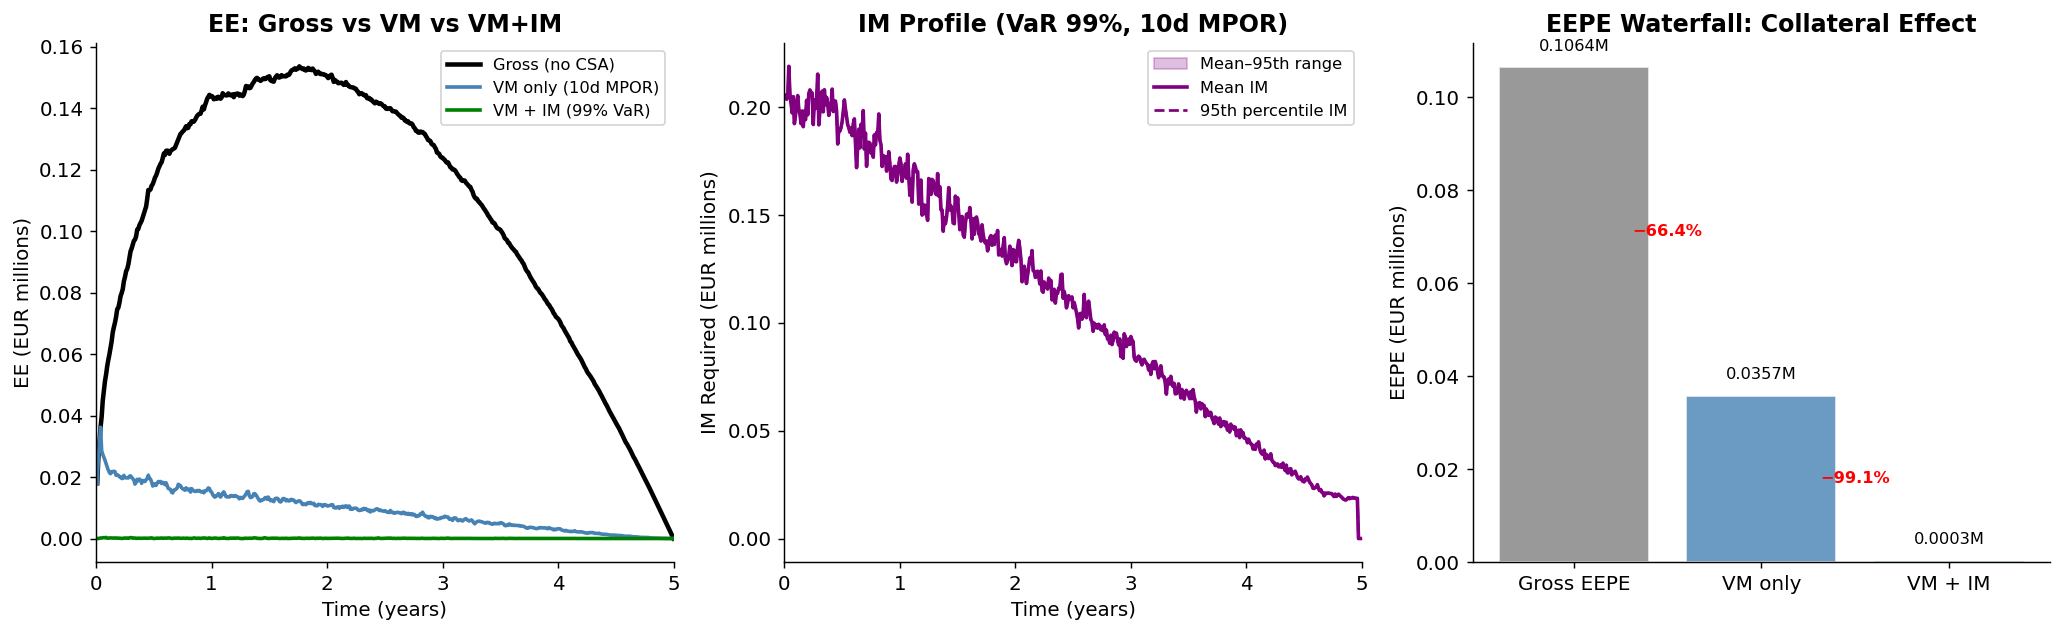


── IM Benefit Summary ────────────────────────────────────────────────────
  Gross EEPE    : EUR 0.1064M
  VM-only EEPE  : EUR 0.0357M  (-66.4%)
  VM+IM EEPE    : EUR 0.0003M  (-99.7%)
  Mean IM required: EUR 0.1086M


In [8]:
csa = CSAParameters.zero_threshold_bilateral(mpor_days=10)
vm_engine = VMEngine(csa)
im_engine = IMEngine(csa, confidence_level=0.99)

vm_matrix = vm_engine.compute_vm_matrix(mtm_matrix, time_grid)
im_matrix = im_engine.var_based_im(mtm_matrix, time_grid)

# Exposures
exp_gross   = np.maximum(mtm_matrix, 0.0)
exp_vm_only = np.maximum(mtm_matrix - vm_matrix, 0.0)
exp_vm_im   = im_engine.exposure_with_im(mtm_matrix, time_grid, vm_matrix)

p_gross_   = ExposureProfile(exp_gross,   time_grid)
p_vm_only  = ExposureProfile(exp_vm_only, time_grid)
p_vm_im    = ExposureProfile(exp_vm_im,   time_grid)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: EE profiles ─────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(time_grid, p_gross_.ee()/1e6,   color='black',      lw=2.5, label='Gross (no CSA)')
ax.plot(time_grid, p_vm_only.ee()/1e6,  color='steelblue',  lw=2.0, label='VM only (10d MPOR)')
ax.plot(time_grid, p_vm_im.ee()/1e6,    color='green',      lw=2.0, label='VM + IM (99% VaR)')
ax.set_title('EE: Gross vs VM vs VM+IM', fontweight='bold')
ax.set_xlabel('Time (years)')
ax.set_ylabel('EE (EUR millions)')
ax.legend(fontsize=9)
ax.set_xlim(0, HORIZON)

# ── Middle: IM profile (mean, 95th percentile) ────────────────────────────────
ax2 = axes[1]
im_mean = im_matrix.mean(axis=0)
im_95   = np.quantile(im_matrix, 0.95, axis=0)
ax2.fill_between(time_grid, im_mean/1e6, im_95/1e6, alpha=0.25, color='purple', label='Mean–95th range')
ax2.plot(time_grid, im_mean/1e6, color='purple', lw=2.0, label='Mean IM')
ax2.plot(time_grid, im_95/1e6,   color='purple', lw=1.5, ls='--', label='95th percentile IM')
ax2.set_title('IM Profile (VaR 99%, 10d MPOR)', fontweight='bold')
ax2.set_xlabel('Time (years)')
ax2.set_ylabel('IM Required (EUR millions)')
ax2.legend(fontsize=9)
ax2.set_xlim(0, HORIZON)

# ── Right: Exposure reduction waterfall ──────────────────────────────────────
ax3 = axes[2]
stages = ['Gross EEPE', 'VM only', 'VM + IM']
eepes  = [p_gross_.eepe(), p_vm_only.eepe(), p_vm_im.eepe()]
bar_c  = ['grey', 'steelblue', 'green']
bars   = ax3.bar(stages, [v/1e6 for v in eepes], color=bar_c, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, eepes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val/1e6:.4f}M', ha='center', va='bottom', fontsize=9)
# Reduction arrows
for i in range(len(eepes)-1):
    reduction = (eepes[i] - eepes[i+1]) / eepes[i] * 100
    ax3.annotate(f'−{reduction:.1f}%',
                 xy=(i + 0.5, (eepes[i] + eepes[i+1]) / 2 / 1e6),
                 ha='center', va='center', fontsize=9, color='red',
                 fontweight='bold')
ax3.set_ylabel('EEPE (EUR millions)')
ax3.set_title('EEPE Waterfall: Collateral Effect', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n── IM Benefit Summary ────────────────────────────────────────────────────')
print(f'  Gross EEPE    : EUR {p_gross_.eepe()/1e6:.4f}M')
print(f'  VM-only EEPE  : EUR {p_vm_only.eepe()/1e6:.4f}M  (-{100*(1-p_vm_only.eepe()/p_gross_.eepe()):.1f}%)')
print(f'  VM+IM EEPE    : EUR {p_vm_im.eepe()/1e6:.4f}M  (-{100*(1-p_vm_im.eepe()/p_gross_.eepe()):.1f}%)')
print(f'  Mean IM required: EUR {im_mean.mean()/1e6:.4f}M')

## 8. SIMM vs VaR-Based IM Comparison

**ISDA SIMM** is a sensitivity-based model used in industry for UMR (Uncleared Margin Rules).
For an IRS, the dominant risk factor is interest rate delta (DV01).

$$IM_{SIMM} \approx |DV01| \times \sigma_{rates} \times \sqrt{\frac{MPOR}{252}} \times z_{0.99}$$

This can be compared to the VaR-from-simulation approach used in `IMEngine.var_based_im()`.

── SIMM vs VaR-Based IM ──────────────────────────────────────────────────
  Swap DV01 (at r=3%)    : EUR -4,607.09 per bp
  HW rate volatility σ   : 1.0% per annum
  MPOR                   : 10 days = 0.0397 years

  SIMM simplified IM     : EUR 339
  VaR-based IM (mean)    : EUR 108,609
  Ratio SIMM/VaR         : 0.00×

  Note: SIMM uses a fixed supervisory volatility per tenor bucket.
  The path-based VaR captures path-dependent volatility more accurately.


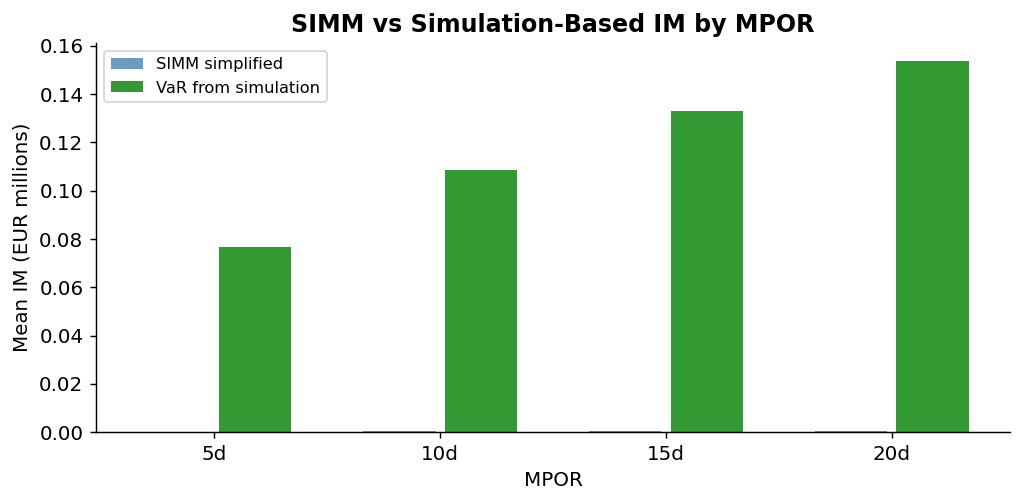

In [9]:
from ccr.instruments import IRSwap

swap = IRSwap(notional=NOTIONAL, fixed_rate=FIXED_RATE, maturity=HORIZON)
dv01 = swap.dv01(0.03)  # DV01 at current rate (EUR per 1bp)

# SIMM simplified
simm_im = im_engine.simm_im_simplified(
    portfolio_dv01=dv01,
    rate_vol=0.010  # HW sigma = 1% per year
)
var_im_mean = im_matrix.mean()  # Average VaR-based IM across all paths and times

print('── SIMM vs VaR-Based IM ──────────────────────────────────────────────────')
print(f'  Swap DV01 (at r=3%)    : EUR {dv01:,.2f} per bp')
print(f'  HW rate volatility σ   : 1.0% per annum')
print(f'  MPOR                   : 10 days = {10/252:.4f} years')
print(f'')
print(f'  SIMM simplified IM     : EUR {simm_im:,.0f}')
print(f'  VaR-based IM (mean)    : EUR {var_im_mean:,.0f}')
print(f'  Ratio SIMM/VaR         : {simm_im/var_im_mean:.2f}×')
print(f'')
print('  Note: SIMM uses a fixed supervisory volatility per tenor bucket.')
print('  The path-based VaR captures path-dependent volatility more accurately.')

# Vary MPOR: compare SIMM vs simulation
mpors_im = [5, 10, 15, 20]
simm_by_mpor = []
var_by_mpor  = []
for mpor in mpors_im:
    csa_m  = CSAParameters.zero_threshold_bilateral(mpor_days=mpor)
    im_m   = IMEngine(csa_m, confidence_level=0.99)
    simm_m = im_m.simm_im_simplified(dv01, 0.010)
    var_m  = im_m.var_based_im(mtm_matrix, time_grid).mean()
    simm_by_mpor.append(simm_m)
    var_by_mpor.append(var_m)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(mpors_im))
ax.bar(x - 0.18, [v/1e6 for v in simm_by_mpor], 0.32, color='steelblue', alpha=0.8, label='SIMM simplified')
ax.bar(x + 0.18, [v/1e6 for v in var_by_mpor],  0.32, color='green',     alpha=0.8, label='VaR from simulation')
ax.set_xticks(x)
ax.set_xticklabels([f'{m}d' for m in mpors_im])
ax.set_xlabel('MPOR')
ax.set_ylabel('Mean IM (EUR millions)')
ax.set_title('SIMM vs Simulation-Based IM by MPOR', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. CollateralManager Full Report

The `CollateralManager` provides an end-to-end collateral analysis report comparing:
- **Gross exposure** (no collateral)
- **VM-only** (variation margin, no IM)
- **VM + IM** (full collateral)

This is the key diagnostic table for a counterparty credit risk (CCR) manager.

In [10]:
csa_full = CSAParameters.zero_threshold_bilateral(mpor_days=10)
cm = CollateralManager(
    csa=csa_full,
    mtm_matrix=mtm_matrix,
    time_grid=time_grid,
    include_im=True,
    im_confidence=0.99,
)

report = cm.full_report()

print('══ CollateralManager Full Report ════════════════════════════════════════')
for scenario, metrics in report.items():
    if scenario == 'CSA_params':
        continue
    print(f'\n  {scenario}')
    print(f'  {"─" * 60}')
    for k, v in metrics.items():
        print(f'    {k:<12}: EUR {v/1e6:>10.4f}M')

print('\n  CSA Parameters')
print(f'  {"─" * 60}')
for k, v in report['CSA_params'].items():
    print(f'    {k:<20}: {v}')

# Summary table
print('\n── Summary: EAD Reduction ────────────────────────────────────────────────')
gross_ead = report['Gross (no collateral)']['EAD_IMM']
for scenario, metrics in report.items():
    if scenario == 'CSA_params':
        continue
    ead = metrics['EAD_IMM']
    print(f'  {scenario:<30}: EAD={ead/1e6:.4f}M  '
          f'(-{100*(1-ead/gross_ead):.1f}%)')

══ CollateralManager Full Report ════════════════════════════════════════

  Gross (no collateral)
  ────────────────────────────────────────────────────────────
    EPE         : EUR     0.1068M
    EEPE        : EUR     0.1064M
    EAD_IMM     : EUR     0.1490M
    MaxPFE      : EUR     0.6376M
    MaxEE       : EUR     0.1536M
    n_paths     : EUR     0.0020M

  VM only
  ────────────────────────────────────────────────────────────
    EPE         : EUR     0.0187M
    EEPE        : EUR     0.0357M
    EAD_IMM     : EUR     0.0500M
    MaxPFE      : EUR     0.1445M
    MaxEE       : EUR     0.0362M
    n_paths     : EUR     0.0020M

  VM + IM
  ────────────────────────────────────────────────────────────
    EPE         : EUR     0.0001M
    EEPE        : EUR     0.0003M
    EAD_IMM     : EUR     0.0005M
    MaxPFE      : EUR     0.0000M
    MaxEE       : EUR     0.0003M
    n_paths     : EUR     0.0020M

  CSA Parameters
  ──────────────────────────────────────────────────────────

## 10. Summary — Key Takeaways

| Concept | Key Insight |
|---|---|
| **VM eliminates level exposure** | Collateralised exposure ≈ MtM change over MPOR, not the level |
| **MPOR scales exposure ~√δ** | Doubling MPOR increases EEPE by ~41% (√2 factor) |
| **Clearing vs bilateral** | 5d MPOR (CCP) vs 10d (bilateral) → ~30% lower EEPE |
| **Threshold adds uncollateralised buffer** | TH=€200k adds a permanent floor to exposure |
| **Dispute scenario doubles MPOR** | CRR3 Art. 285(4): operational risk has capital cost |
| **IM reduces residual gap risk** | VM+IM can reduce exposure by 85-95% vs gross |
| **SIMM is conservative vs simulation** | SIMM uses fixed supervisory volatility → typically higher IM |